<a href="https://colab.research.google.com/github/mdzubayereashraf/Ostad-AI-Engineering-Course-Assignments/blob/main/Assignmen_No_15(Image_Classification_with_Deep_Learning_and_CNNs).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Part A: Data Preparation**

# **Image Classification with Deep Learning and CNNs**

## **Introduction**

The objective of this project is to compare a fully connected neural network with a Convolutional Neural Network (CNN) on the Fashion-MNIST dataset. The project covers data preparation, model building, training, evaluation, and error analysis. It also explores why CNNs are particularly effective for image classification and how their architecture affects model performance.


### **Import Libraries**

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout

### **Dataset load**

In [4]:
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

print("Full training images:", X_train_full.shape)
print("Full training labels:", y_train_full.shape)
print("Test images:", X_test.shape)
print("Test labels:", y_test.shape)

Full training images: (60000, 28, 28)
Full training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)


### **Show Ten Sample Images**

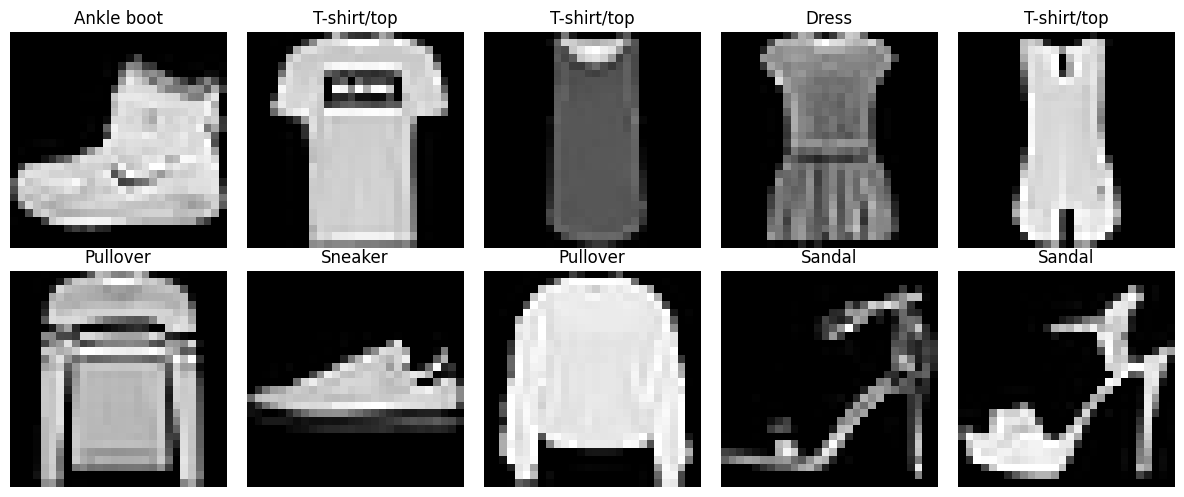

In [5]:

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train_full[i], cmap="gray")
    plt.title(class_names[y_train_full[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

### **Normalize ও validation split**

In [7]:

X_train_full = X_train_full.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0


rng = np.random.default_rng(42)
indices = rng.permutation(len(X_train_full))

X_train_full = X_train_full[indices]
y_train_full = y_train_full[indices]


X_val = X_train_full[:5000]
y_val = y_train_full[:5000]

X_train = X_train_full[5000:]
y_train = y_train_full[5000:]

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)
print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Training: (55000, 28, 28)
Validation: (5000, 28, 28)
Test: (10000, 28, 28)
Minimum pixel value: 0.0
Maximum pixel value: 0.003921569


# **Part B: Baseline Neural Network**

### **Baseline Neural Network**

In [10]:
dense_model = Sequential([
    Flatten(input_shape=(28, 28)),

    Dense(256, activation="relu"),
    Dropout(0.3),

    Dense(128, activation="relu"),
    Dropout(0.2),

    Dense(10, activation="softmax")
])


dense_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

### **Compile the Model**

In [11]:
dense_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### **Train the Model**

In [13]:
history_dense = dense_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=128,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8229 - loss: 0.4872 - val_accuracy: 0.8448 - val_loss: 0.4279
Epoch 2/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8321 - loss: 0.4633 - val_accuracy: 0.8514 - val_loss: 0.4085
Epoch 3/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8385 - loss: 0.4478 - val_accuracy: 0.8568 - val_loss: 0.3969
Epoch 4/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8448 - loss: 0.4320 - val_accuracy: 0.8560 - val_loss: 0.3956
Epoch 5/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8484 - loss: 0.4195 - val_accuracy: 0.8660 - val_loss: 0.3736
Epoch 6/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8524 - loss: 0.4077 - val_accuracy: 0.8678 - val_loss: 0.3673
Epoch 7/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8544 - loss: 0.4029 - val_accuracy: 0.8652 - val_loss: 0.3696
Epoch 8/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8579 - loss: 0.3903 - val_accuracy: 

### **Save the Model**

In [14]:
dense_model.save('/content/drive/MyDrive/dense_model.keras')

### **Plot Training vs Validation Accuracy**

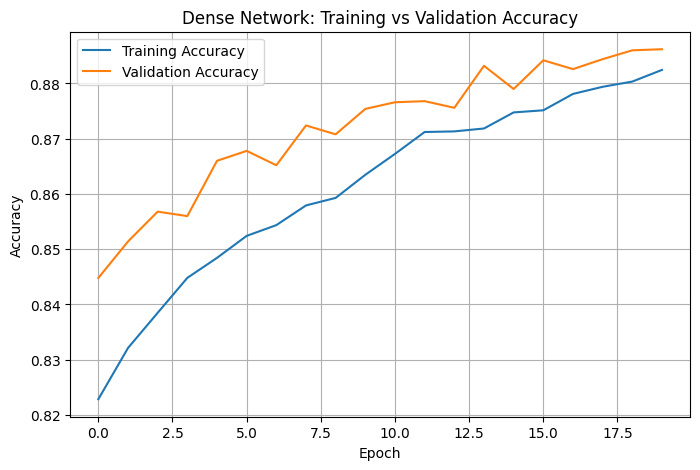

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_dense.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_dense.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Dense Network: Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()